# AWS Glue Studio Notebook
##### You are now running a AWS Glue Studio notebook; To start using your notebook you need to start an AWS Glue Interactive Session.


####  Run this cell to set up and start your interactive session.


In [1]:
%idle_timeout 2880
%glue_version 5.1
%worker_type G.1X
%number_of_workers 5

import sys
from awsglue.transforms import *
from awsglue.utils import getResolvedOptions
from pyspark.context import SparkContext
from awsglue.context import GlueContext
from awsglue.job import Job
  
sc = SparkContext.getOrCreate()
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)

Welcome to the Glue Interactive Sessions Kernel
For more information on available magic commands, please type %help in any new cell.

Please view our Getting Started page to access the most up-to-date information on the Interactive Sessions kernel: https://docs.aws.amazon.com/glue/latest/dg/interactive-sessions.html
Installed kernel version: 1.0.10 
Current idle_timeout is None minutes.
idle_timeout has been set to 2880 minutes.
Setting Glue version to: 5.1
Previous worker type: None
Setting new worker type to: G.1X
Previous number of workers: None
Setting new number of workers to: 5
Trying to create a Glue session for the kernel.
Session Type: glueetl
Worker Type: G.1X
Number of Workers: 5
Idle Timeout: 2880
Session ID: 7699d3a0-1549-41cb-9bcf-aff9277235d0
Applying the following default arguments:
--glue_kernel_version 1.0.10
--enable-glue-datacatalog true
Waiting for session 7699d3a0-1549-41cb-9bcf-aff9277235d0 to get into ready status...
Session 7699d3a0-1549-41cb-9bcf-aff9277235d0 

#### Example: Create a DynamicFrame from a table in the AWS Glue Data Catalog and display its schema


In [3]:
vendas_zoop_silver_dyf = glueContext.create_dynamic_frame.from_catalog(database = 'db-glue-zoop', table_name = 'zoop-glue-vendas_zoop_silver')
#vendas_zoop_silver_dyf.printSchema()

root
|-- id_venda: long
|-- data: date
|-- horario: timestamp
|-- canal_venda: string
|-- origem_venda: string
|-- id_produto: long
|-- produto: string
|-- categoria_produto: string
|-- preco_unitario: double
|-- quantidade: int
|-- metodo_pagamento: string
|-- id_cliente: long
|-- nome_cliente: string
|-- genero_cliente: string
|-- idade_cliente: int
|-- cidade_cliente: string
|-- uf_cliente: string
|-- regiao_cliente: string
|-- avaliacao: int


#### Example: Convert the DynamicFrame to a Spark DataFrame and display a sample of the data


In [4]:
vendas_zoop_silver_df = vendas_zoop_silver_dyf.toDF().toPandas()
#vendas_zoop_silver_df.head(5)

   id_venda        data  ... regiao_cliente avaliacao
0      7379  2023-11-10  ...        Sudeste         5
1      7815  2023-12-28  ...        Sudeste         1
2      7022  2023-10-03  ...       Nordeste         5
3      9046  2024-05-08  ...        Sudeste         3
4      8088  2024-01-24  ...   Centro-Oeste         3

[5 rows x 19 columns]
/usr/lib/spark/python/lib/pyspark.zip/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.


#### Example: Visualize data with matplotlib


In [5]:
import matplotlib.pyplot as plt

In [6]:
#%pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 226.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 178.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 109.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [seaborn]m8/9 [seaborn]ib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /usr/local/bin/.pyenv/versions/3.9.9/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import seaborn as sns

In [9]:
# Produtos com maior volume de venda por região

vendas_agrupadas = vendas_zoop_silver_df.groupby(['produto', 'regiao_cliente'])['quantidade'].sum().reset_index()
#vendas_agrupadas.head(5)

           produto regiao_cliente  quantidade
0  Aparelho de som   Centro-Oeste          76
1  Aparelho de som       Nordeste         154
2  Aparelho de som          Norte          50
3  Aparelho de som        Sudeste         367
4  Aparelho de som            Sul          58


In [10]:
#ordenar produtos pelos mais vendidos

top_5_produtos = vendas_agrupadas.groupby('produto')['quantidade'].sum().nlargest(5).index

#top_5_produtos

Index(['Smartphone', 'Chuveiro elétrico', 'Máquina de café',
       'Secador de cabelo', 'Liquidificador'],
      dtype='object', name='produto')


In [11]:
# filtrar os 5 produtos mais vendidos

vendas_top_5 = vendas_agrupadas[vendas_agrupadas['produto'].isin(top_5_produtos)].reset_index()

#vendas_top_5

    index            produto regiao_cliente  quantidade
0      25  Chuveiro elétrico   Centro-Oeste          58
1      26  Chuveiro elétrico       Nordeste         170
2      27  Chuveiro elétrico          Norte          36
3      28  Chuveiro elétrico        Sudeste         407
4      29  Chuveiro elétrico            Sul          50
5      75     Liquidificador   Centro-Oeste          74
6      76     Liquidificador       Nordeste         173
7      77     Liquidificador          Norte          42
8      78     Liquidificador        Sudeste         364
9      79     Liquidificador            Sul          60
10     85    Máquina de café   Centro-Oeste          83
11     86    Máquina de café       Nordeste         101
12     87    Máquina de café          Norte          46
13     88    Máquina de café        Sudeste         432
14     89    Máquina de café            Sul          58
15    110  Secador de cabelo   Centro-Oeste          75
16    111  Secador de cabelo       Nordeste     

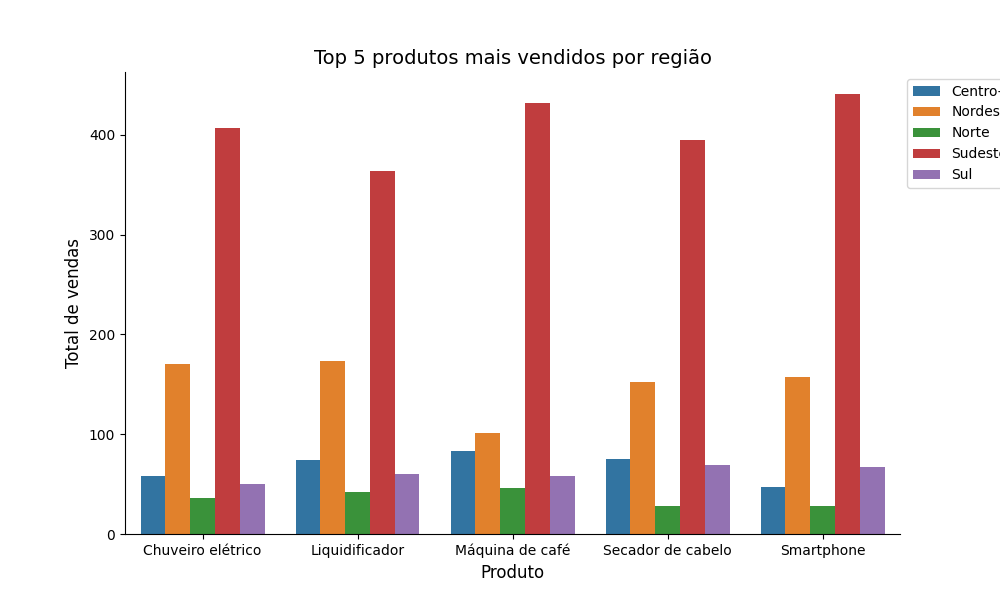

In [13]:
# visualizar gráfico de vendas dos 5 produtos mais vendidos por região

plt.figure(figsize = (10, 6))
sns.barplot(data = vendas_top_5, x = 'produto', y = 'quantidade', hue = 'regiao_cliente')
plt.legend(bbox_to_anchor = (1, 1))
plt.title('Top 5 produtos mais vendidos por região', fontsize = 14)
plt.xticks(rotation = 0)
plt.ylabel('Total de vendas', fontsize = 12)
plt.xlabel('Produto', fontsize = 12)
sns.despine()

%matplot plt

In [22]:
# agrupar os dados por canal de venda e calcular o total de vendas por canal

vendas_por_canal = vendas_zoop_silver_df.groupby('canal_venda')['quantidade'].sum().reset_index()
vendas_por_canal = vendas_por_canal.sort_values('quantidade', ascending = False)

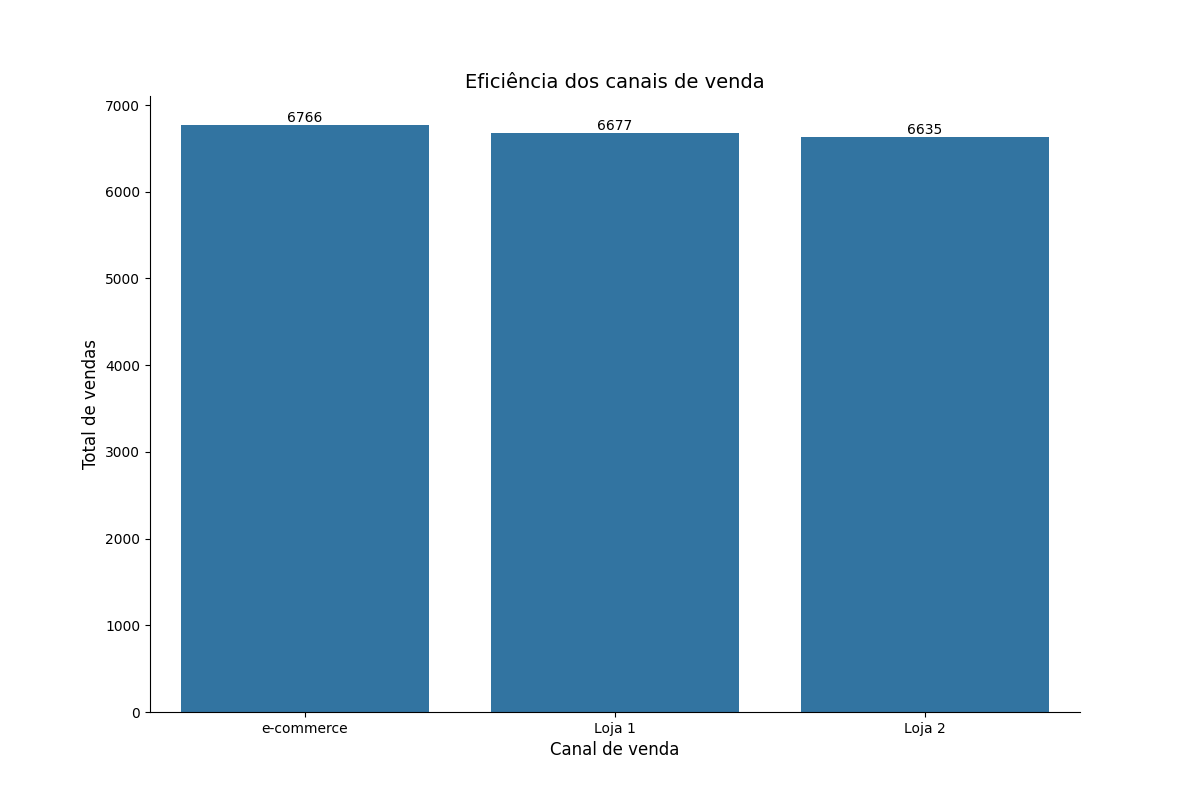

In [27]:
# plotar o gráfico de vendas por canal de venda
plt.figure(figsize = (12, 8))
ax = sns.barplot(data = vendas_por_canal, x = 'canal_venda', y = 'quantidade')
plt.title('Eficiência dos canais de venda', fontsize = 14)
plt.ylabel('Total de vendas', fontsize = 12)
plt.xlabel('Canal de venda', fontsize = 12)
sns.despine()

# adicionando os rótulos às barras
ax.bar_label(ax.containers[0])

%matplot plt